In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[6,6,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


#### Data source: https://www.kaggle.com/datasets/nikunjhemani/freddie-macs-dataset-pre-processed/code
#### Feature selection: https://www.kaggle.com/code/missionjee/feature-selection

In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('FreddieMac.csv')
df['LTV_range'] = df['LTV_range'].map({'Low': -1, 'Medium': 0, 'High':1})

# Select features and target variable
'''features = df[['Repay_range', 'LTV_range', 'FirstTimeHomebuyer', 'NumBorrowers','MonthsInRepayment', 'OrigUPB', 
               'OrigInterestRate', 'MIP', 'Maturity_Year', 'FirstPayment_Year','MSA', 'DTI']].values'''  

features = df[['Repay_range', 'MonthsInRepayment', 'OrigUPB', 'MIP', 'MSA', 'DTI']].values     
    
# features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1}).values

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}
# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([148938, 6]), torch.Size([148938]))

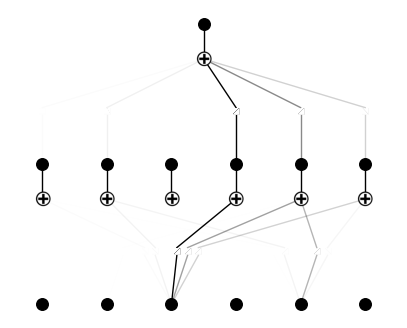

In [3]:
dataset = {
    'train_input': dataset['train_input'][:3000],
    'train_label': dataset['train_label'][:3000],
    'test_input': dataset['test_input'][:3000],
    'test_label': dataset['test_label'][:3000]
}

# plot KAN at initialization
model(dataset['train_input']);
model.plot();
# model.plot(beta=100,sample=True)

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 1.66e+01 | : 100%|█| 100/100 [01:31<00:00,  1.09


saving model version 0.1


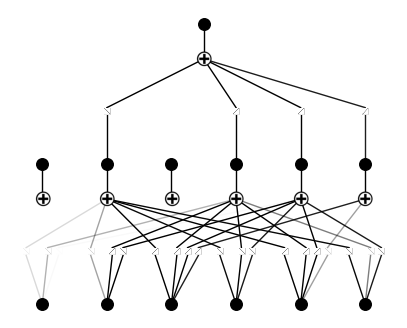

In [4]:
model.fit(dataset, opt="LBFGS", steps=100, lamb=0.001);
model.plot()

saving model version 0.2


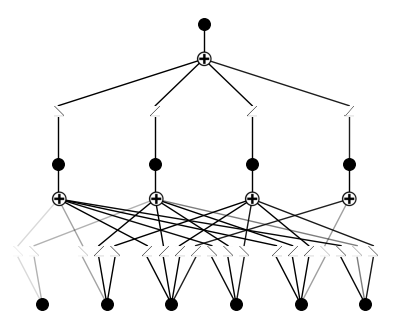

In [5]:
model = model.prune()
model.plot()

In [6]:
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(5)

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 3.97e+01 | : 100%|█| 50/50 [00:22<00:00,  2.25it

saving model version 0.3
saving model version 0.4


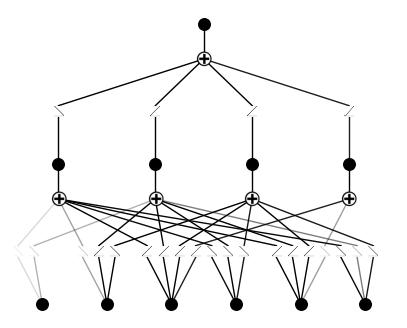

In [7]:
model.plot()

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 3.97e+01 | : 100%|█| 50/50 [00:26<00:00,  1.88it


saving model version 0.5
saving model version 0.6


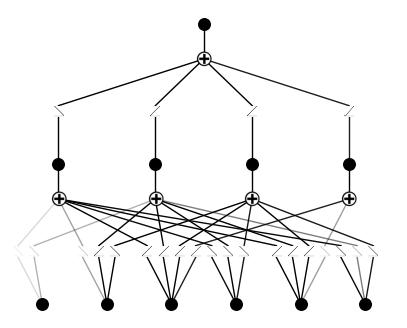

In [8]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()
model = model.refine(10)

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 3.97e+01 | : 100%|█| 50/50 [00:25<00:00,  1.93it


saving model version 0.7
saving model version 0.8


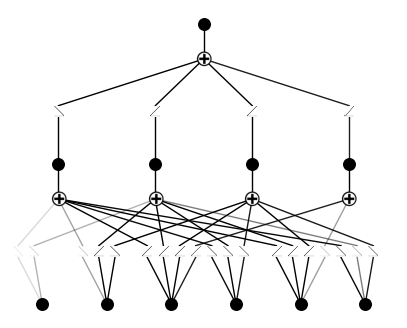

In [9]:
# model.fit(dataset, opt="LBFGS", steps=50,lamb=0.001);
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()
model = model.refine(25)

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 3.97e+01 | : 100%|█| 50/50 [00:37<00:00,  1.35it


saving model version 0.9


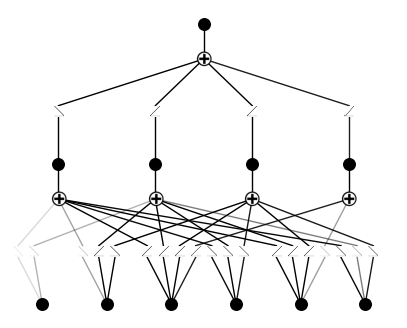

In [10]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

| train_loss: 5.94e-01 | test_loss: 5.94e-01 | reg: 3.97e+01 | : 100%|█| 50/50 [00:43<00:00,  1.15it


saving model version 0.10


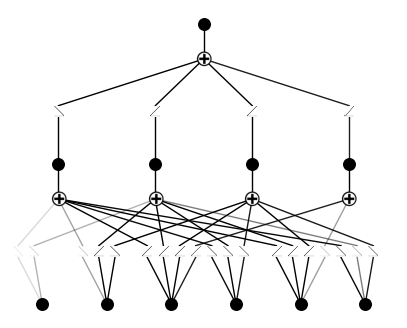

In [11]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

In [12]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
ex_round(formula, 4)
# nsimplify(ex_round(formula, 4))

fixing (0,0,0) with x, r2=0.9997541308403015, c=1
fixing (0,0,1) with x, r2=0.9998946785926819, c=1
fixing (0,0,2) with 0
fixing (0,0,3) with 0
fixing (0,1,0) with x, r2=1.0000003576278687, c=1
fixing (0,1,1) with x, r2=1.000000238418579, c=1
fixing (0,1,2) with x, r2=1.0000003576278687, c=1
fixing (0,1,3) with 0
fixing (0,2,0) with x, r2=1.0000003576278687, c=1
fixing (0,2,1) with x, r2=1.0000004768371582, c=1
fixing (0,2,2) with x, r2=1.0000005960464478, c=1
fixing (0,2,3) with x, r2=1.0000004768371582, c=1
fixing (0,3,0) with x, r2=1.0000007152557373, c=1
fixing (0,3,1) with x, r2=1.0000005960464478, c=1
fixing (0,3,2) with x, r2=1.0000003576278687, c=1
fixing (0,3,3) with 0
fixing (0,4,0) with x, r2=1.0000004768371582, c=1
fixing (0,4,1) with x, r2=1.0000005960464478, c=1
fixing (0,4,2) with x, r2=1.0000004768371582, c=1
fixing (0,4,3) with x, r2=1.0000004768371582, c=1
fixing (0,5,0) with x, r2=0.9999988675117493, c=1
fixing (0,5,1) with x, r2=0.9999989867210388, c=1
fixing (0,5,2

-0.0127*x_1 + 0.0005*x_2 - 0.0168*x_4 + 0.0001*x_6 + 0.0162